# MAC0508 EP2

Pipeline completo: 
- preparação do córpus
- tradução zero-shot
- fine-tuning few-shot
- avaliação.


In [1]:
import json
from datetime import datetime
import pandas as pd
import torch

from src.config import CORPUS_URL, DATA_DIR, DEFAULT_MODEL, RESULTS_DIR, RANDOM_SEED
from src.corpus import download_corpus, load_and_clean_corpus, split_corpus, save_splits, analyze_corpus
from src.translation import ZeroShotTranslator, FewShotTrainer, TrainingConfig
from src.evaluation import evaluate_all_results, save_metrics, analyze_examples

print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Device count: {torch.cuda.device_count()}")
if torch.cuda.is_available():
    print(f"Current device: {torch.cuda.current_device()}")
    print(f"Device name: {torch.cuda.get_device_name(0)}")
print(f"Modelo selecionado: {DEFAULT_MODEL}")


CUDA available: True
Device count: 1
Current device: 0
Device name: NVIDIA GeForce RTX 5070 Ti
Modelo selecionado: facebook/nllb-200-distilled-600M


## 1. Preparação do Córpus


In [2]:
DATA_DIR.mkdir(parents=True, exist_ok=True)
excel_path = DATA_DIR / "corpus_original.xlsx"

if not excel_path.exists():
    download_corpus(CORPUS_URL, excel_path)

df = load_and_clean_corpus(excel_path)
analyze_corpus(df)

train_df, val_df, test_df = split_corpus(df, random_seed=RANDOM_SEED)
save_splits(train_df, val_df, test_df, DATA_DIR)


Carregando córpus de /home/murakams/IME/graduation-ime-usp/static/ime/MAC0508/ep2/code/data/corpus_original.xlsx...
Colunas encontradas: ['PortuguÊs', 'Tupi Antigo']
Número de linhas original: 7097
Mapeamento de colunas: {'portugues': 'PortuguÊs', 'tupi_antigo': 'Tupi Antigo'}
Número de pares após limpeza: 6974

Estatísticas do Córpus
Total de pares: 6974

Português:
  Média de caracteres: 35.7
  Média de palavras:   6.4

Tupi Antigo:
  Média de caracteres: 26.2
  Média de palavras:   3.9

Divisão do córpus:
  Treino:      4881 (70.0%)
  Validação:   1046 (15.0%)
  Teste:       1047 (15.0%)

Arquivos salvos em /home/murakams/IME/graduation-ime-usp/static/ime/MAC0508/ep2/code/data:
  - train.csv (4881 pares)
  - val.csv (1046 pares)
  - test.csv (1047 pares)


## 2. Tradução Zero-Shot (NLLB com Guarani como proxy)


In [3]:
test_df = pd.read_csv(DATA_DIR / "test.csv")
translator = ZeroShotTranslator(model_name=DEFAULT_MODEL)

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
zero_shot_results = {
    "model": DEFAULT_MODEL,
    "timestamp": datetime.now().isoformat(),
    "test_size": len(test_df),
}

for direction, src_col, tgt_col in [("pt_to_ta", "portugues", "tupi_antigo"), ("ta_to_pt", "tupi_antigo", "portugues")]:
    sources = test_df[src_col].tolist()
    refs = test_df[tgt_col].tolist()
    preds = translator.translate_batch(sources, direction=direction)
    zero_shot_results[direction] = {"sources": sources, "references": refs, "predictions": preds}

with open(RESULTS_DIR / f"zero_shot_{DEFAULT_MODEL.replace('/', '_')}.json", "w", encoding="utf-8") as f:
    json.dump(zero_shot_results, f, ensure_ascii=False, indent=2)


Carregando modelo: facebook/nllb-200-distilled-600M
Dispositivo: cuda
Modo: NLLB (language codes)
Modelo carregado!


Traduzindo (ta_to_pt): 100%|██████████| 1047/1047 [01:51<00:00,  9.37it/s]


## 3. Fine-tuning Few-Shot (NLLB)


In [3]:
train_df = pd.read_csv(DATA_DIR / "train.csv")
val_df = pd.read_csv(DATA_DIR / "val.csv")
test_df = pd.read_csv(DATA_DIR / "test.csv")

config = TrainingConfig(batch_size=4, learning_rate=5e-5, num_epochs=30, early_stopping_patience=5)
trainer = FewShotTrainer(model_name=DEFAULT_MODEL, config=config)

few_shot_results = {"model": DEFAULT_MODEL, "config": config.__dict__, "timestamp": datetime.now().isoformat()}

for direction, src_col, tgt_col in [("pt_to_ta", "portugues", "tupi_antigo"), ("ta_to_pt", "tupi_antigo", "portugues")]:
    model_path = trainer.train(train_df, val_df, direction)
    sources = test_df[src_col].tolist()
    refs = test_df[tgt_col].tolist()
    preds = trainer.translate(model_path, sources, direction)
    few_shot_results[direction] = {"model_path": model_path, "sources": sources, "references": refs, "predictions": preds}

with open(RESULTS_DIR / f"few_shot_{DEFAULT_MODEL.replace('/', '_')}.json", "w", encoding="utf-8") as f:
    json.dump(few_shot_results, f, ensure_ascii=False, indent=2)


Inicializando FewShotTrainer
  Modelo: facebook/nllb-200-distilled-600M
  Tipo: NLLB
  Dispositivo: cuda

Treinando: pt_to_ta
  Criando datasets para pt_to_ta...
  Train: 4881, Val: 1046
  Sample input_ids length: 47
  Sample labels length: 54


Step,Training Loss,Validation Loss
50,5.036100,4.691266
100,3.916200,3.692048
150,3.462400,3.254643
200,3.072100,2.997736
250,2.942000,2.791721
300,2.767400,2.641739
350,2.417900,2.531935
400,2.406300,2.423063
450,2.289300,2.331523
500,2.086600,2.273649


/home/murakams/.pyenv/versions/3.13.5/envs/mac0508/lib/python3.13/site-packages/transformers/modeling_utils.py:3918: UserWarning: Moving the following attributes in the config to the generation config: {'max_length': 200}. You are seeing this warning because you've set generation parameters in the model config, as opposed to in the generation config.
  warnings.warn(
There were missing keys in the checkpoint model loaded: ['model.encoder.embed_tokens.weight', 'model.decoder.embed_tokens.weight', 'lm_head.weight'].


Modelo salvo em: /home/murakams/IME/graduation-ime-usp/static/ime/MAC0508/ep2/code/models/facebook_nllb-200-distilled-600M_pt_to_ta/final


The tokenizer you are loading from '/home/murakams/IME/graduation-ime-usp/static/ime/MAC0508/ep2/code/models/facebook_nllb-200-distilled-600M_pt_to_ta/final' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.
Traduzindo: 100%|██████████| 1047/1047 [02:01<00:00,  8.60it/s]



Treinando: ta_to_pt
  Criando datasets para ta_to_pt...
  Train: 4881, Val: 1046
  Sample input_ids length: 54
  Sample labels length: 47


Step,Training Loss,Validation Loss
50,3.673800,3.375207
100,3.206600,3.057149
150,3.028100,2.853887
200,2.741700,2.705965
250,2.673000,2.607547
300,2.564000,2.522897
350,2.271300,2.471761
400,2.342200,2.399747
450,2.189600,2.346912
500,1.992300,2.319119


/home/murakams/.pyenv/versions/3.13.5/envs/mac0508/lib/python3.13/site-packages/transformers/modeling_utils.py:3918: UserWarning: Moving the following attributes in the config to the generation config: {'max_length': 200}. You are seeing this warning because you've set generation parameters in the model config, as opposed to in the generation config.
  warnings.warn(
There were missing keys in the checkpoint model loaded: ['model.encoder.embed_tokens.weight', 'model.decoder.embed_tokens.weight', 'lm_head.weight'].


Modelo salvo em: /home/murakams/IME/graduation-ime-usp/static/ime/MAC0508/ep2/code/models/facebook_nllb-200-distilled-600M_ta_to_pt/final


The tokenizer you are loading from '/home/murakams/IME/graduation-ime-usp/static/ime/MAC0508/ep2/code/models/facebook_nllb-200-distilled-600M_ta_to_pt/final' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.
Traduzindo: 100%|██████████| 1047/1047 [02:00<00:00,  8.72it/s]


## 4. Avaliação


In [2]:
metrics_df = evaluate_all_results(RESULTS_DIR)
print("\n" + metrics_df.to_string(index=False))
save_metrics(metrics_df, RESULTS_DIR)


Processando: few_shot_facebook_nllb-200-distilled-600M.json
  pt_to_ta: BLEU=27.52, chrF1=32.83, chrF3=42.10
  ta_to_pt: BLEU=50.00, chrF1=49.12, chrF3=50.63

Processando: zero_shot_facebook_nllb-200-distilled-600M.json
  pt_to_ta: BLEU=5.52, chrF1=13.43, chrF3=16.75
  ta_to_pt: BLEU=45.18, chrF1=30.53, chrF3=22.15

Experimento                           Modelo Direção      BLEU     chrF1     chrF3
   few-shot facebook/nllb-200-distilled-600M   PT→TA 27.516060 32.831509 42.095939
   few-shot facebook/nllb-200-distilled-600M   TA→PT 50.000000 49.116890 50.633207
  zero-shot facebook/nllb-200-distilled-600M   PT→TA  5.522398 13.426924 16.750609
  zero-shot facebook/nllb-200-distilled-600M   TA→PT 45.180100 30.530706 22.152600
Métricas salvas em /home/murakams/IME/graduation-ime-usp/static/ime/MAC0508/ep2/code/results


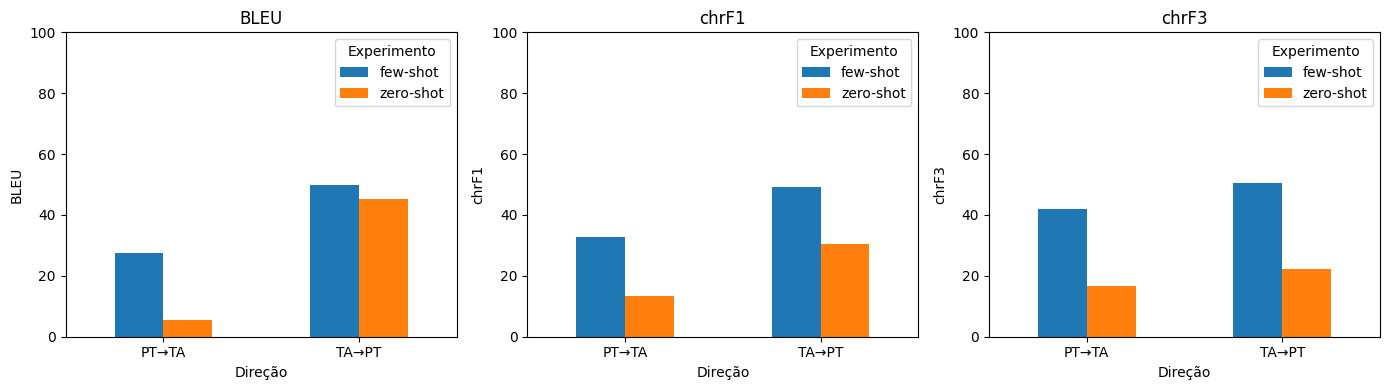

In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for idx, metric in enumerate(["BLEU", "chrF1", "chrF3"]):
    pivot = metrics_df.pivot_table(index="Direção", columns="Experimento", values=metric, aggfunc="mean")
    pivot.plot(kind="bar", ax=axes[idx], rot=0)
    axes[idx].set_title(metric)
    axes[idx].set_ylabel(metric)
    axes[idx].set_ylim(0, 100)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "metrics_comparison.png", dpi=150)
plt.show()



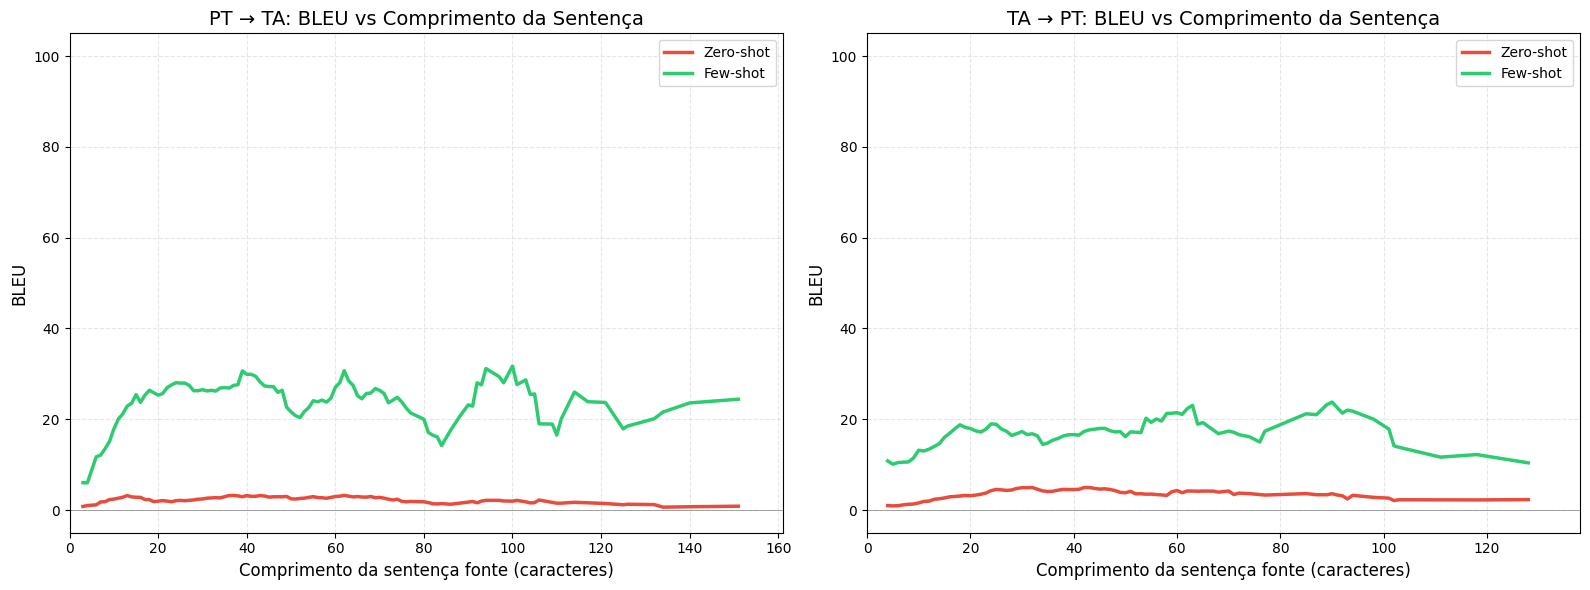

In [9]:
import numpy as np
from src.evaluation import TranslationEvaluator

def load_results(path):
    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f)

def rolling_mean(lengths, scores, window=10):
    df = pd.DataFrame({'length': lengths, 'bleu': scores}).sort_values('length')
    grouped = df.groupby('length')['bleu'].mean().reset_index()
    grouped['bleu_smooth'] = grouped['bleu'].rolling(window=window, center=True, min_periods=1).mean()
    return grouped['length'].values, grouped['bleu_smooth'].values

evaluator = TranslationEvaluator()
zero_shot_data = load_results(RESULTS_DIR / "zero_shot_facebook_nllb-200-distilled-600M.json")
few_shot_data = load_results(RESULTS_DIR / "few_shot_facebook_nllb-200-distilled-600M.json")

data_points = {}
for name, data in [("Zero-shot", zero_shot_data), ("Few-shot", few_shot_data)]:
    for direction in ["pt_to_ta", "ta_to_pt"]:
        dir_data = data[direction]
        df = evaluator.evaluate_per_sentence(dir_data["predictions"], dir_data["references"])
        data_points[f"{name}_{direction}"] = ([len(s) for s in dir_data["sources"]], df["bleu"].tolist())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax1 = axes[0]
for name, color in [("Zero-shot", "#e74c3c"), ("Few-shot", "#2ecc71")]:
    lengths, scores = data_points[f"{name}_pt_to_ta"]
    x_smooth, y_smooth = rolling_mean(lengths, scores, window=10)
    ax1.plot(x_smooth, y_smooth, color=color, linewidth=2.5, label=name)

ax1.set_xlabel('Comprimento da sentença fonte (caracteres)', fontsize=12)
ax1.set_ylabel('BLEU', fontsize=12)
ax1.set_title('PT → TA: BLEU vs Comprimento da Sentença', fontsize=14)
ax1.legend(loc='upper right')
ax1.set_ylim(-5, 105)
ax1.set_xlim(0, max(lengths) + 10)
ax1.grid(alpha=0.3, linestyle='--')
ax1.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)

ax2 = axes[1]
for name, color in [("Zero-shot", "#e74c3c"), ("Few-shot", "#2ecc71")]:
    lengths, scores = data_points[f"{name}_ta_to_pt"]
    x_smooth, y_smooth = rolling_mean(lengths, scores, window=10)
    ax2.plot(x_smooth, y_smooth, color=color, linewidth=2.5, label=name)

ax2.set_xlabel('Comprimento da sentença fonte (caracteres)', fontsize=12)
ax2.set_ylabel('BLEU', fontsize=12)
ax2.set_title('TA → PT: BLEU vs Comprimento da Sentença', fontsize=14)
ax2.legend(loc='upper right')
ax2.set_ylim(-5, 105)
ax2.set_xlim(0, max(lengths) + 10)
ax2.grid(alpha=0.3, linestyle='--')
ax2.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "bleu_by_sentence_length.png", dpi=150)
plt.show()


In [11]:
from src.evaluation import TranslationEvaluator

def show_examples(results_file, title, n=5):
    with open(results_file, 'r', encoding='utf-8') as f:
        data = json.load(f)
    
    evaluator = TranslationEvaluator()
    for direction in ["pt_to_ta", "ta_to_pt"]:
        dir_data = data[direction]
        df = evaluator.evaluate_per_sentence(dir_data["predictions"], dir_data["references"])
        df["source"] = dir_data["sources"]
        df = df.sort_values("bleu", ascending=False)
        
        dir_label = "PT→TA" if direction == "pt_to_ta" else "TA→PT"
        print(f"\n{'='*80}\n{title} | {dir_label}\n{'='*80}")
        
        print(f"\nMELHORES {n}:")
        for i, (_, row) in enumerate(df.head(n).iterrows()):
            print(f"{i+1}. BLEU={row['bleu']:.0f} | {row['source']} → {row['prediction']}")
        
        print(f"\nPIORES {n}:")
        for i, (_, row) in enumerate(df.tail(n).iterrows()):
            print(f"{i+1}. BLEU={row['bleu']:.0f} | {row['source']} → {row['prediction']}")

show_examples(RESULTS_DIR / "zero_shot_facebook_nllb-200-distilled-600M.json", "ZERO-SHOT")
show_examples(RESULTS_DIR / "few_shot_facebook_nllb-200-distilled-600M.json", "FEW-SHOT")



ZERO-SHOT | PT→TA

MELHORES 5:
1. BLEU=55 | Quem és tu? → ¿Mávapa nde?
2. BLEU=50 | tuas palavras → nde ñe'ẽnguéra
3. BLEU=50 | rego d'água → oje'u y
4. BLEU=50 | Preparai-vos! → Peñembosako'i!
5. BLEU=28 | Afasta-te! → Eju ndehegui!

PIORES 5:
1. BLEU=0 | Estou de acordo com ele → Añe'ẽ porã hese.
2. BLEU=0 | Frustrei-me → Añeñandu vaieterei
3. BLEU=0 | Fiz todos os jejuns → Ajapo opa mba'e ho'u va'ekue
4. BLEU=0 | Somos vizinhos uns dos outros → Ñañemoirũ ojuehe
5. BLEU=0 | Longamente eu o estive fazendo → Heta ára ajapo va'ekue

ZERO-SHOT | TA→PT

MELHORES 5:
1. BLEU=76 | Salve Rainha, moraûsubara sy → Salve Rainha, mãe de moraúsubara
2. BLEU=55 | Emogûeb tatá → Queimem o fogo
3. BLEU=51 | Tupã sy-porangeté → Mãe de Deus
4. BLEU=50 | Peîemosako'i! → Preparem-se!
5. BLEU=50 | Eîepe'a! → Abre!

PIORES 5:
1. BLEU=0 | Aîmoîoakypûé-kypûer → Eu coloquei-o no chão-de-cabeça
2. BLEU=0 | mby piru'a → abóbora
3. BLEU=0 | Na xe îuru-pyki → Na xe îuru-pyki
4. BLEU=0 | Xe roby-kanugûá → Xe roby